# 03 – Narrative Volatility Index (NVI)


## 1. Introduction

Traditional GDELT-based studies primarily focus on:

- Conflict event prediction  
- Aggregated Goldstein scores  
- Event count–based risk indices  

However, these approaches largely ignore the **volatility of media narratives over time**.

To address this limitation, this study introduces the **Narrative Volatility Index (NVI)**.

Rather than measuring the absolute level of conflict, the NVI captures **how unstable a country's media narrative is within a rolling time window**.

This approach allows us to analyze narrative instability as a dynamic phenomenon emerging from changes in tone, systemic impact, and event structure.

## 2. Conceptual Framework

Narrative volatility may arise from multiple mechanisms within media systems.

Three dimensions are considered:

- **Affective volatility** — variation in media tone  
- **Systemic volatility** — changes in cooperation–conflict balance (Goldstein score)  
- **Structural volatility** — diversity of event types within narratives

These dimensions jointly capture how unstable the narrative environment of a country becomes over time.

## 3. Data Source

The analysis is based on **GDELT event data** stored in a DuckDB database.

The database contains several intermediate tables generated during the preprocessing pipeline. 
For the Narrative Volatility Index construction, we use the **`exports_clean`** table, which contains cleaned event-level records.

This table includes key variables such as:

- Event tone (`tone`)
- Goldstein score (`goldstein`)
- Event QuadClass (`quadclass`)
- Country identifiers
- Event timestamps

These cleaned event-level observations serve as the input for the subsequent country–month aggregation and volatility estimation steps.

In [39]:
import duckdb

# Connect to the DuckDB database
con = duckdb.connect("../data/intermediate/gdelt.db")

# Display all tables in the database
con.execute("SHOW TABLES").fetchdf()

,name
0,country_month_features
1,exports
2,exports_clean
3,incoming_country_month
4,narrative_country_month
5,narrative_country_month_pilot
6,narrative_nvi_pilot
7,narrative_volatility_filtered
8,narrative_volatility_final
9,narrative_volatility_pilot


In [40]:
# Preview the cleaned event table
con.execute("""
SELECT *
FROM exports_clean
LIMIT 5
""").fetchdf()

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1276919265,20241201,202412,2024,2024.9068,USA,LOUISVILLE,USA,NaN,EDU,...,0,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,20251201000000,https://www.whas11.com/article/news/education/...
1,1276919266,20251101,202511,2025,2025.8247,USAGOV,THE WHITE HOUSE,USA,GOV,USA,...,3,"Chicago, Illinois, United States",US,USIL,IL031,41.8500,-87.6501,423587,20251201000000,https://www.chicagotribune.com/2025/11/30/trum...
2,1276919267,20251101,202511,2025,2025.8247,USAGOV,THE WHITE HOUSE,USA,GOV,USA,...,3,"White House, District of Columbia, United States",US,USDC,NaN,38.8951,-77.0364,531871,20251201000000,https://www.chicagotribune.com/2025/11/30/trum...
3,1276919268,20251124,202511,2025,2025.8877,BEL,WATERLOO,BEL,NaN,COP,...,4,"Sydney, New South Wales, Australia",AS,AS02,154637,-33.8833,151.2170,-1603135,20251201000000,https://www.northerndailyleader.com.au/story/9...
4,1276919269,20251124,202511,2025,2025.8877,COP,POLICE,Unknown,COP,BEL,...,4,"Sydney, New South Wales, Australia",AS,AS02,154637,-33.8833,151.2170,-1603135,20251201000000,https://www.northerndailyleader.com.au/story/9...


## 4. Aggregation

Event-level observations are aggregated to the **country–month level**
to construct country-specific narrative indicators.

For each country and month, we compute:

- Total number of events (`event_count`)
- Mean and standard deviation of event tone (`tone_mean`, `tone_std`)
- Mean and standard deviation of Goldstein score (`goldstein_mean`, `goldstein_std`)
- Distribution of events across the four QuadClass categories (`quad1_ratio` – `quad4_ratio`)

Only observations with valid `Actor1CountryCode` values are included in the aggregation.

### 4.1 Create Country–Month Aggregation

In [41]:
con.execute("""
CREATE OR REPLACE TABLE narrative_country_month AS
SELECT
    DATE_TRUNC(
        'month',
        STRPTIME(CAST(Day AS VARCHAR), '%Y%m%d')
    ) AS year_month,

    Actor1CountryCode AS country,

    COUNT(*) AS event_count,

    AVG(AvgTone) AS tone_mean,
    STDDEV(AvgTone) AS tone_std,

    AVG(GoldsteinScale) AS goldstein_mean,
    STDDEV(GoldsteinScale) AS goldstein_std,

    SUM(CASE WHEN QuadClass = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad1_ratio,
    SUM(CASE WHEN QuadClass = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad2_ratio,
    SUM(CASE WHEN QuadClass = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad3_ratio,
    SUM(CASE WHEN QuadClass = 4 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS quad4_ratio

FROM exports_clean
WHERE Actor1CountryCode IS NOT NULL
AND Actor1CountryCode != 'Unknown'

GROUP BY 1,2;
""")

### 4.2 Inspect Aggregated Data

To verify that the aggregation was performed correctly,
we preview the first rows of the `narrative_country_month` table.

In [42]:
con.execute("""
SELECT *
FROM narrative_country_month
ORDER BY country, year_month
LIMIT 10
""").fetchdf()

,year_month,country,event_count,tone_mean,tone_std,goldstein_mean,goldstein_std,quad1_ratio,quad2_ratio,quad3_ratio,quad4_ratio
0,2025-12-01,ABW,148,-0.784610,4.965363,1.844595,3.025207,0.851351,0.054054,0.033784,0.060811
1,2026-01-01,ABW,177,-1.055729,3.426101,1.612429,2.970760,0.768362,0.101695,0.016949,0.112994
2,2026-02-01,ABW,32,0.702506,3.260808,3.018750,2.495730,0.875000,0.093750,0.031250,0.000000
3,2015-12-01,AFG,2,-11.728395,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,1.000000
4,2024-12-01,AFG,58,-5.428983,2.963311,-2.098276,5.152226,0.431034,0.068966,0.155172,0.344828
5,2025-01-01,AFG,89,-4.447925,3.680039,-1.316854,5.354782,0.494382,0.056180,0.179775,0.269663
6,2025-02-01,AFG,51,-5.312432,5.458044,-1.521569,6.063178,0.392157,0.156863,0.117647,0.333333
7,2025-11-01,AFG,264,-5.361152,2.926959,-3.413258,5.584179,0.340909,0.064394,0.155303,0.439394
8,2025-12-01,AFG,10299,-4.388024,4.117265,-0.819128,5.533438,0.481600,0.124284,0.125837,0.268278
9,2026-01-01,AFG,7431,-3.506990,3.957693,-0.109285,5.516134,0.525098,0.136321,0.127843,0.210739


### 4.3 Create Pilot Dataset

For the pilot study, we restrict the analysis to a
three-month window from **December 2025 to February 2026**.

This subset allows rapid prototyping of the Narrative
Volatility Index before extending the analysis to a
longer time horizon.

In [43]:
con.execute("""
CREATE OR REPLACE TABLE narrative_country_month_pilot AS
SELECT *
FROM narrative_country_month
WHERE year_month BETWEEN DATE '2025-12-01' AND DATE '2026-02-01';
""")

### 4.4 Verify Pilot Dataset Dates

We confirm that the pilot dataset contains only the intended months.

In [44]:
con.execute("""
SELECT DISTINCT year_month
FROM narrative_country_month_pilot
ORDER BY year_month
""").fetchdf()

,year_month
0,2025-12-01
1,2026-01-01
2,2026-02-01


## 5. Structural Entropy

To capture narrative diversity, **Shannon entropy** is computed over the
QuadClass distribution.

     H = - Σ (p_i * log(p_i))

where \(p_i\) is the proportion of events in QuadClass \(i\) for a given
country–month.

**Interpretation**

- Low entropy → narrative concentrated in a single event type
- High entropy → heterogeneous event structure

Entropy serves as a proxy for **structural narrative fragmentation**
within national media narratives.

### 5.1 Add Entropy Column

In [45]:
# Add column for QuadClass entropy
con.execute("""
ALTER TABLE narrative_country_month_pilot
ADD COLUMN quad_entropy DOUBLE;
""")

### 5.2 Compute Shannon Entropy

In [46]:
# Compute Shannon entropy for each row
con.execute("""
UPDATE narrative_country_month_pilot
SET quad_entropy =
- (
    COALESCE(quad1_ratio * LN(NULLIF(quad1_ratio,0)), 0) +
    COALESCE(quad2_ratio * LN(NULLIF(quad2_ratio,0)), 0) +
    COALESCE(quad3_ratio * LN(NULLIF(quad3_ratio,0)), 0) +
    COALESCE(quad4_ratio * LN(NULLIF(quad4_ratio,0)), 0)
);
""")

### 5.3 Inspect Entropy Values

We preview the country–month observations with the highest entropy
values to examine highly heterogeneous narrative structures.

In [47]:
# Preview top 10 rows by entropy
con.execute("""
SELECT country, year_month,
       quad1_ratio, quad2_ratio, quad3_ratio, quad4_ratio,
       quad_entropy
FROM narrative_country_month_pilot
ORDER BY quad_entropy DESC
LIMIT 10
""").fetchdf()

,country,year_month,quad1_ratio,quad2_ratio,quad3_ratio,quad4_ratio,quad_entropy
0,HND,2025-12-01,0.386540,0.273224,0.153005,0.187230,1.322835
1,NER,2026-01-01,0.418622,0.106737,0.222559,0.252082,1.285121
2,STP,2025-12-01,0.428571,0.238095,0.095238,0.238095,1.270442
3,MOZ,2026-02-01,0.482993,0.207483,0.136054,0.173469,1.253073
4,NER,2026-02-01,0.441441,0.081081,0.217503,0.259974,1.246712
5,BFA,2026-01-01,0.402044,0.122658,0.117547,0.357751,1.243116
6,HND,2026-01-01,0.464716,0.187608,0.093804,0.253873,1.240099
7,GEO,2025-12-01,0.277778,0.055556,0.388889,0.277778,1.239497
8,PSE,2025-12-01,0.469217,0.105818,0.160513,0.264453,1.238108
9,ERI,2025-12-01,0.440711,0.083004,0.179842,0.296443,1.236685


## 6. Volatility

Narrative volatility is estimated using a **rolling three-month window**.

For each country, we compute the rolling standard deviation of:

- Mean event tone (`tone_mean`)
- Mean Goldstein score (`goldstein_mean`)
- Structural entropy (`quad_entropy`)

The rolling window includes the **current month and the two preceding months**.

Volatility captures **dispersion in narrative signals rather than their absolute level**.

### 6.1 Compute Rolling Volatility

In [48]:
# Compute 3-month rolling volatility for tone, goldstein, and entropy
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility_pilot AS
SELECT
    country,
    year_month,

    STDDEV(tone_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS tone_vol,

    STDDEV(goldstein_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS goldstein_vol,

    STDDEV(quad_entropy) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS entropy_vol

FROM narrative_country_month_pilot;
""")

### 6.2 Inspect Volatility Estimates

We preview the computed volatility values for each country–month
to ensure that the rolling window calculation behaves as expected.

In [49]:
con.execute("""
SELECT *
FROM narrative_volatility_pilot
ORDER BY country, year_month
LIMIT 20
""").fetchdf()

,country,year_month,tone_vol,goldstein_vol,entropy_vol
0,ABW,2025-12-01,NaN,NaN,NaN
1,ABW,2026-01-01,0.191710,0.164166,0.120880
2,ABW,2026-02-01,0.946609,0.753910,0.152075
3,AFG,2025-12-01,NaN,NaN,NaN
4,AFG,2026-01-01,0.622985,0.501935,0.016846
5,AFG,2026-02-01,0.449359,0.371013,0.017000
6,AFR,2025-12-01,NaN,NaN,NaN
7,AFR,2026-01-01,0.027917,0.161530,0.002372
8,AFR,2026-02-01,0.035890,0.127780,0.018133
9,AGO,2025-12-01,NaN,NaN,NaN


## 7. NVI Construction

**Objective:** Compute a cross-sectional **Narrative Volatility Index (NVI)** for each country, based on the rolling volatilities computed in Section 6.

**Steps:**

1. **Select the final month** (`2026-02-01`) to focus on a snapshot of volatility.  
2. **Filter countries** to ensure sufficient data quality:  
   - Total events ≥ 60  
   - Minimum monthly events ≥ 10  
   - Non-null rolling volatilities (`tone_vol`, `goldstein_vol`, `entropy_vol`)  

3. **Compute z-scores** for each volatility component:

$$
z_x = \frac{x - \mu_x}{\sigma_x}
$$

where:  
- \(x\) is the volatility component (tone, Goldstein, or entropy)  
- \(\mu_x\) is the mean across countries  
- \(\sigma_x\) is the standard deviation across countries  

4. **Aggregate z-scores** into the composite NVI:

$$
\text{NVI} = z_{\text{tone\_vol}} + z_{\text{goldstein\_vol}} + z_{\text{entropy\_vol}}
$$

> Higher NVI values indicate greater narrative instability across countries.

### 7.1 SQL Implementation

In [50]:
# Select the final month for cross-sectional analysis
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility_final AS
SELECT *
FROM narrative_volatility_pilot
WHERE year_month = DATE '2026-02-01';
""")

In [51]:
# Filter countries with sufficient events and valid volatilities
con.execute("""
CREATE OR REPLACE TABLE narrative_volatility_filtered AS
SELECT v.*
FROM narrative_volatility_final v
JOIN (
    SELECT country, SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_month_pilot
    GROUP BY country
) e
ON v.country = e.country
WHERE e.total_events >= 60
  AND e.min_monthly_events >= 10
  AND tone_vol IS NOT NULL
  AND goldstein_vol IS NOT NULL
  AND entropy_vol IS NOT NULL;
""")

In [52]:
# Compute z-scores and final NVI
con.execute("""
CREATE OR REPLACE TABLE narrative_nvi_pilot AS
SELECT *,
       (tone_vol - AVG(tone_vol) OVER ()) / NULLIF(STDDEV(tone_vol) OVER (), 0) AS z_tone_vol,
       (goldstein_vol - AVG(goldstein_vol) OVER ()) / NULLIF(STDDEV(goldstein_vol) OVER (), 0) AS z_goldstein_vol,
       (entropy_vol - AVG(entropy_vol) OVER ()) / NULLIF(STDDEV(entropy_vol) OVER (), 0) AS z_entropy_vol,
       ((tone_vol - AVG(tone_vol) OVER ()) / NULLIF(STDDEV(tone_vol) OVER (), 0) +
        (goldstein_vol - AVG(goldstein_vol) OVER ()) / NULLIF(STDDEV(goldstein_vol) OVER (), 0) +
        (entropy_vol - AVG(entropy_vol) OVER ()) / NULLIF(STDDEV(entropy_vol) OVER (), 0)) AS NVI
FROM narrative_volatility_filtered;
""")

In [53]:
# Retrieve top 10 countries by NVI
df = con.execute("""
SELECT country, NVI, tone_vol, goldstein_vol, entropy_vol
FROM narrative_nvi_pilot
ORDER BY NVI DESC
""").fetchdf()

df.head(10)

,country,NVI,tone_vol,goldstein_vol,entropy_vol
0,GNQ,11.593199,1.903957,2.550298,0.297567
1,NRU,6.561264,2.882699,0.982666,0.132317
2,SWZ,6.156499,1.466936,1.369235,0.221584
3,SAF,5.934525,1.252959,1.359534,0.238285
4,URY,5.391206,1.650451,0.751225,0.275174
5,TGO,5.374047,1.439157,1.248187,0.194789
6,CAF,5.315055,1.339738,0.753123,0.313991
7,CRB,5.229846,1.140059,0.758641,0.335323
8,LBY,5.094750,1.428612,1.375127,0.147787
9,AIA,4.935801,1.964823,0.324434,0.290481


## 8. NVI Analysis

**Objective:** Analyze the cross-sectional NVI values to identify narrative instability patterns across countries.

**Steps:**

1. Visualize the **distribution** of NVI values across countries.
2. Identify **thresholds** for labeling regimes (`Stable`, `Low`, `Shock`).
3. Assign each country a **categorical regime label** based on its NVI.
4. Prepare the dataset for further clustering and comparison.

In [54]:
df['NVI'].quantile([0.25, 0.5, 0.75])

0.25   -1.757533
0.50   -0.657990
0.75    1.244701
Name: NVI, dtype: float64

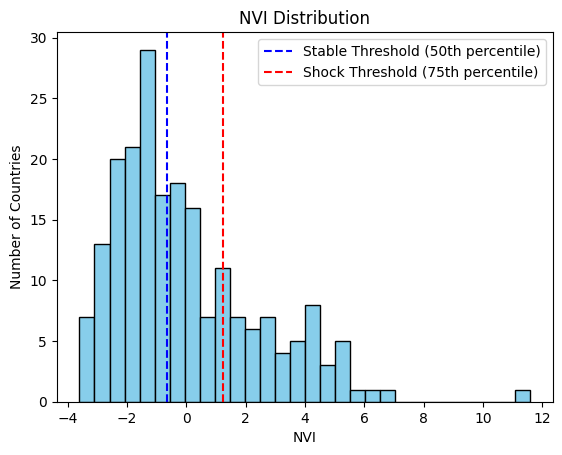

,country,NVI,nvi_label
0,GNQ,11.593199,Shock
1,NRU,6.561264,Shock
2,SWZ,6.156499,Shock
3,SAF,5.934525,Shock
4,URY,5.391206,Shock
5,TGO,5.374047,Shock
6,CAF,5.315055,Shock
7,CRB,5.229846,Shock
8,LBY,5.094750,Shock
9,AIA,4.935801,Shock


In [55]:
# Visualize NVI distribution
import matplotlib.pyplot as plt

# Compute quantiles once
q50 = df['NVI'].quantile(0.5)
q75 = df['NVI'].quantile(0.75)

# Histogram of NVI distribution
plt.hist(df['NVI'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(q50, color='blue', linestyle='--', label='Stable Threshold (50th percentile)')
plt.axvline(q75, color='red', linestyle='--', label='Shock Threshold (75th percentile)')
plt.title("NVI Distribution")
plt.xlabel("NVI")
plt.ylabel("Number of Countries")
plt.legend()
plt.show()

# Assign regime labels based on quantiles
def nvi_label(nvi):
    if nvi > q75:
        return 'Shock'
    elif nvi < q50:
        return 'Stable'
    else:
        return 'Low'

df['nvi_label'] = df['NVI'].apply(nvi_label)

# Preview labeled countries
df[['country','NVI','nvi_label']].sort_values('NVI', ascending=False).head(10)

## 9. Clustering

**Objective:** Perform unsupervised clustering on countries based on their narrative volatilities (`tone_vol`, `goldstein_vol`, `entropy_vol`) to identify discrete **narrative regimes**.

**Steps:**

1. **Select features** for clustering (without using NVI).  
2. **Standardize features** using `StandardScaler`.  
3. Apply **KMeans clustering** with 3 clusters.  
4. **Evaluate clustering** using the Silhouette score.  
5. Visualize clusters in **2D space** using PCA.  
6. Compute cluster-level averages and assign **regime labels** (`Stable`, `Low`, `Shock`) for interpretation.

Silhouette Score: 0.38211755347434967


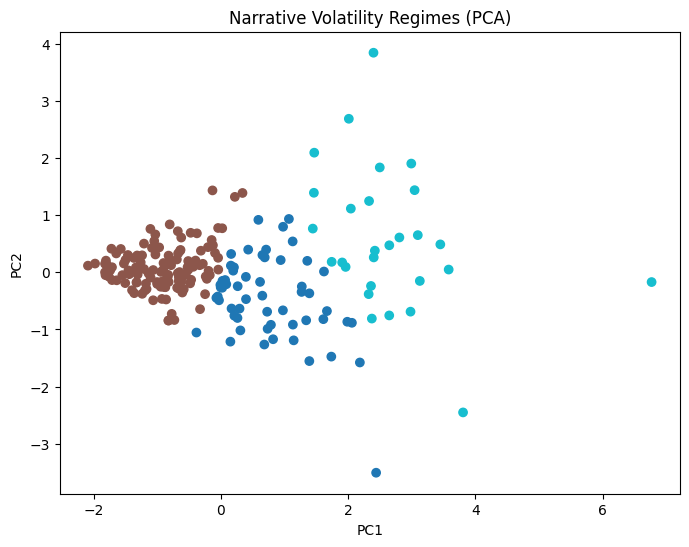

         tone_vol  goldstein_vol  entropy_vol  volatility_score
cluster                                                        
1        0.369928       0.256086     0.054548          0.680563
0        1.061640       0.576872     0.096243          1.734756
2        1.263608       0.935826     0.230730          2.430164
{1: 'Stable', 0: 'Low', 2: 'Shock'}


In [56]:
# Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features for clustering (exclude NVI)
X = df[['tone_vol','goldstein_vol','entropy_vol']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Evaluate clustering
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df['cluster'])
print("Silhouette Score:", score)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='tab10')
plt.title("Narrative Volatility Regimes (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Cluster summary
cluster_summary = df.groupby('cluster')[['tone_vol','goldstein_vol','entropy_vol']].mean()
cluster_summary['volatility_score'] = cluster_summary.sum(axis=1)
cluster_summary = cluster_summary.sort_values('volatility_score')

# Map clusters to regime labels
labels = ["Stable","Low","Shock"]
cluster_label_map = {cluster: label for cluster, label in zip(cluster_summary.index, labels)}
df['kmeans_label'] = df['cluster'].map(cluster_label_map)

# Display cluster summary and label mapping
print(cluster_summary)
print(cluster_label_map)

## 9.1 Global Map of Narrative Regimes (KMeans)

**Objective:** Visualize the clustering results on a world map.

**Steps:**

1. Load country shapefile.  
2. Merge with `kmeans_label` from clustering.  
3. Assign colors to each regime:  
   - `Shock` → red  
   - `Stable` → blue  
   - `Low` → gray  
4. Plot countries with regime colors. Missing countries are light gray.

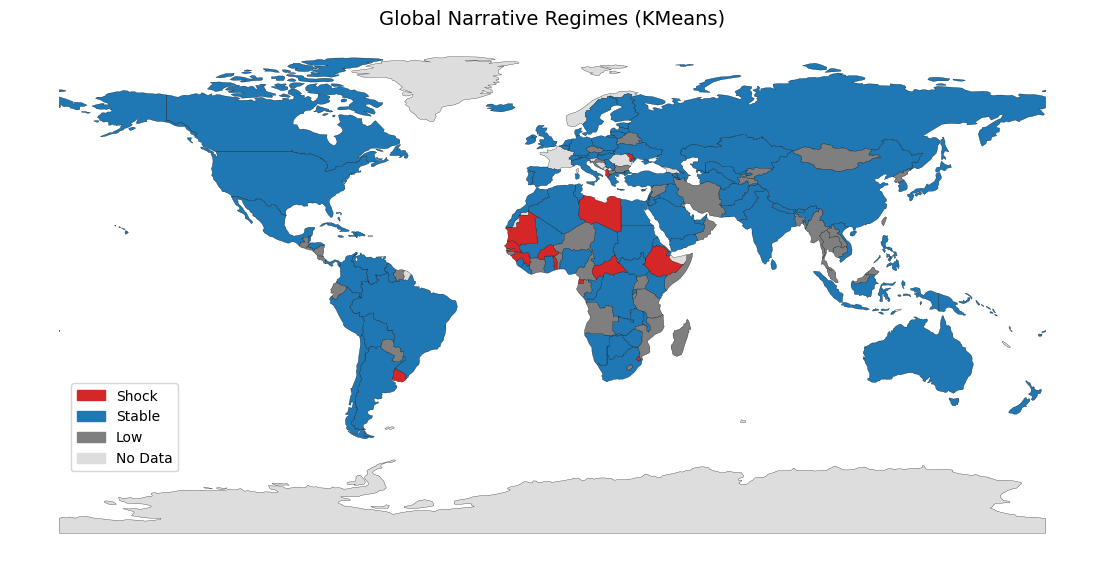

In [58]:
import geopandas as gpd
import zipfile
import tempfile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load country shapefile
zip_path = "../data/external/ne_110m_admin_0_countries.zip"
with zipfile.ZipFile(zip_path) as z:
    shp_file = [f for f in z.namelist() if f.endswith(".shp")][0]
    with tempfile.TemporaryDirectory() as tmpdir:
        z.extractall(tmpdir)
        world = gpd.read_file(f"{tmpdir}/{shp_file}")

# Rename ISO_A3 column for merging
world = world.rename(columns={"ISO_A3": "country"})

# Merge with clustering results
kmeans_map = world.merge(df[['country','kmeans_label']], on="country", how="left")

# Define color map
color_map_kmeans = {
    'Shock': "#d62728",
    'Stable': "#1f77b4",
    'Low': "#7f7f7f"
}

# Legend for KMeans
legend_patches = [
    mpatches.Patch(color="#d62728", label="Shock"),
    mpatches.Patch(color="#1f77b4", label="Stable"),
    mpatches.Patch(color="#7f7f7f", label="Low"),
    mpatches.Patch(color="#dddddd", label="No Data")
]

kmeans_map["color"] = kmeans_map["kmeans_label"].map(color_map_kmeans).fillna("#dddddd")

# Plot map
fig, ax = plt.subplots(figsize=(14,8))
kmeans_map.plot(color=kmeans_map["color"], edgecolor="black", linewidth=0.2, ax=ax)
ax.set_title("Global Narrative Regimes (KMeans)", fontsize=14)
ax.legend(handles=legend_patches, loc='lower left', frameon=True, bbox_to_anchor=(0.05, 0.15))
ax.axis("off")
plt.show()

## 9.2 Global Map of Narrative Volatility Index (NVI)

**Objective:** Compare clustering-based regimes with the continuous NVI measure.

**Steps:**

1. Assign discrete labels to countries based on NVI quantiles.  
2. Merge with world shapefile.  
3. Assign colors to NVI labels:
   - `Shock` → red  
   - `Stable` → blue  
   - `Low` → gray  
4. Plot countries with NVI regime colors. Missing countries are light gray.

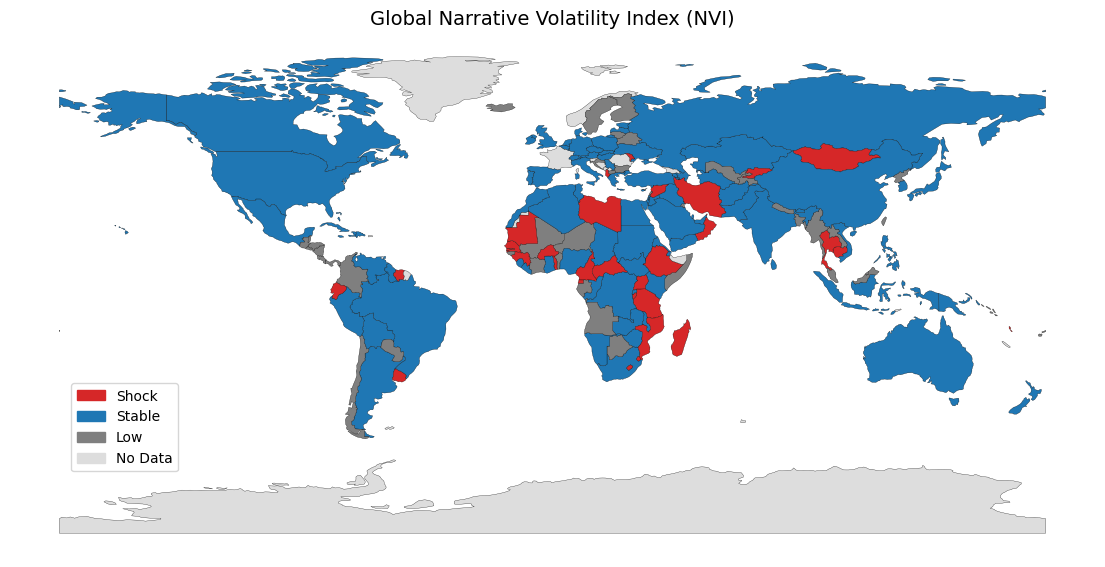

In [59]:
# Merge with world shapefile
nvi_map = world.merge(df[['country','nvi_label']], on="country", how="left")

color_map_nvi = {
    'Shock': "#d62728",
    'Stable': "#1f77b4",
    'Low': "#7f7f7f"
}
legend_patches = [
    mpatches.Patch(color="#d62728", label="Shock"),
    mpatches.Patch(color="#1f77b4", label="Stable"),
    mpatches.Patch(color="#7f7f7f", label="Low"),
    mpatches.Patch(color="#dddddd", label="No Data")
]

nvi_map["color"] = nvi_map["nvi_label"].map(color_map_nvi).fillna("#dddddd")

# Plot NVI map
fig, ax = plt.subplots(figsize=(14,8))
nvi_map.plot(color=nvi_map["color"], edgecolor="black", linewidth=0.2, ax=ax)
ax.legend(handles=legend_patches, loc='lower left', frameon=True, bbox_to_anchor=(0.05, 0.15))
ax.set_title("Global Narrative Volatility Index (NVI)", fontsize=14)
ax.axis("off")
plt.show()

### 9.3 Agreement Between KMeans and NVI Labels

In [60]:
# Compare KMeans labels with NVI labels
comparison_df = df[['country','NVI','kmeans_label','nvi_label']].copy()
comparison_df['same'] = comparison_df['kmeans_label'] == comparison_df['nvi_label']
agreement_rate = comparison_df['same'].mean()

print("Agreement rate between KMeans and NVI labels:", agreement_rate)

# Show countries where labels differ
diff_df = comparison_df[comparison_df['same'] == False].sort_values("NVI", ascending=False)
diff_df.head(20)

Agreement rate between KMeans and NVI labels: 0.7788461538461539


,country,NVI,kmeans_label,nvi_label,same
14,COM,4.222577,Low,Shock,False
21,MDG,3.784089,Low,Shock,False
24,LSO,3.521428,Low,Shock,False
26,ECU,3.378714,Low,Shock,False
29,KHM,2.981113,Low,Shock,False
30,BDI,2.861193,Low,Shock,False
31,MOZ,2.836035,Low,Shock,False
32,IRN,2.754586,Low,Shock,False
36,OMN,2.435706,Low,Shock,False
37,SUR,2.424518,Low,Shock,False


## 10. Method Comparison

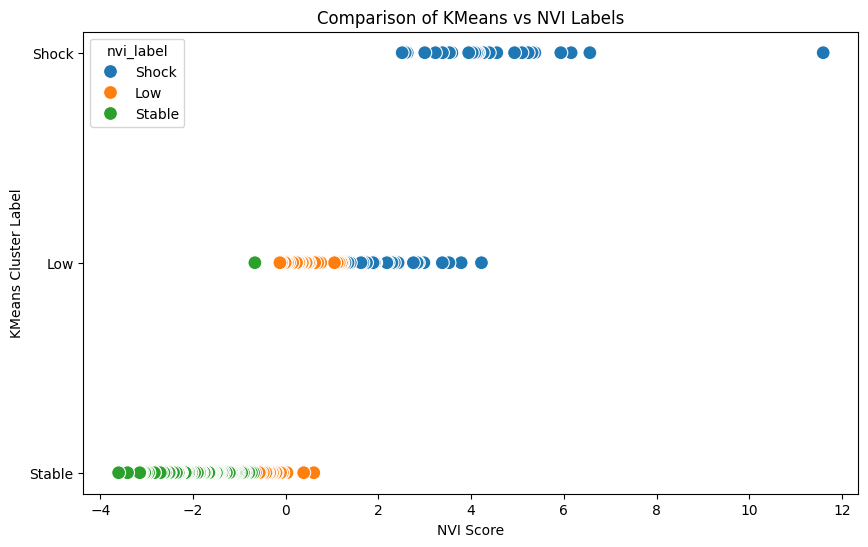

In [61]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=comparison_df, x='NVI', y='kmeans_label', hue='nvi_label', s=100)
plt.title("Comparison of KMeans vs NVI Labels")
plt.xlabel("NVI Score")
plt.ylabel("KMeans Cluster Label")
plt.show()

In [62]:
# Create comparison dataframe
comparison_df = df[['country','NVI','kmeans_label','nvi_label']].copy()
# Check where labels match
comparison_df['same'] = comparison_df['kmeans_label'] == comparison_df['nvi_label']
# Compute overall agreement rate
agreement_rate = comparison_df['same'].mean()
print("Agreement rate between KMeans and NVI labels:", agreement_rate)

Agreement rate between KMeans and NVI labels: 0.7788461538461539


In [63]:
diff_df = comparison_df[comparison_df['same'] == False].sort_values("NVI", ascending=False)
diff_df.head(20)  # Top 20 differing cases

,country,NVI,kmeans_label,nvi_label,same
14,COM,4.222577,Low,Shock,False
21,MDG,3.784089,Low,Shock,False
24,LSO,3.521428,Low,Shock,False
26,ECU,3.378714,Low,Shock,False
29,KHM,2.981113,Low,Shock,False
30,BDI,2.861193,Low,Shock,False
31,MOZ,2.836035,Low,Shock,False
32,IRN,2.754586,Low,Shock,False
36,OMN,2.435706,Low,Shock,False
37,SUR,2.424518,Low,Shock,False


In [64]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(comparison_df['kmeans_label'], comparison_df['nvi_label'])
print("Cohen's Kappa:", kappa)

Cohen's Kappa: 0.632


In [65]:
# Farklı olan ülkeler için detaylı tablo
diff_df = comparison_df[comparison_df['same'] == False].sort_values("NVI", ascending=False)

# Rolling volatility değerlerini de ekle
diff_df = diff_df.merge(
    df[['country','tone_vol','goldstein_vol','entropy_vol']],
    on='country',
    how='left'
)

# Top 20 farklı ülkeyi göster
diff_df.head(20)

,country,NVI,kmeans_label,nvi_label,same,tone_vol,goldstein_vol,entropy_vol
0,COM,4.222577,Low,Shock,False,3.177046,0.412174,0.043808
1,MDG,3.784089,Low,Shock,False,2.178998,0.580751,0.118407
2,LSO,3.521428,Low,Shock,False,1.406610,1.023188,0.112964
3,ECU,3.378714,Low,Shock,False,1.227818,1.154274,0.099361
4,KHM,2.981113,Low,Shock,False,1.758183,0.735526,0.085977
5,BDI,2.861193,Low,Shock,False,1.340429,0.827898,0.117067
6,MOZ,2.836035,Low,Shock,False,1.457167,0.452952,0.181073
7,IRN,2.754586,Low,Shock,False,1.313426,0.876151,0.102485
8,OMN,2.435706,Low,Shock,False,2.134304,0.235199,0.101980
9,SUR,2.424518,Low,Shock,False,1.452317,0.480250,0.145510


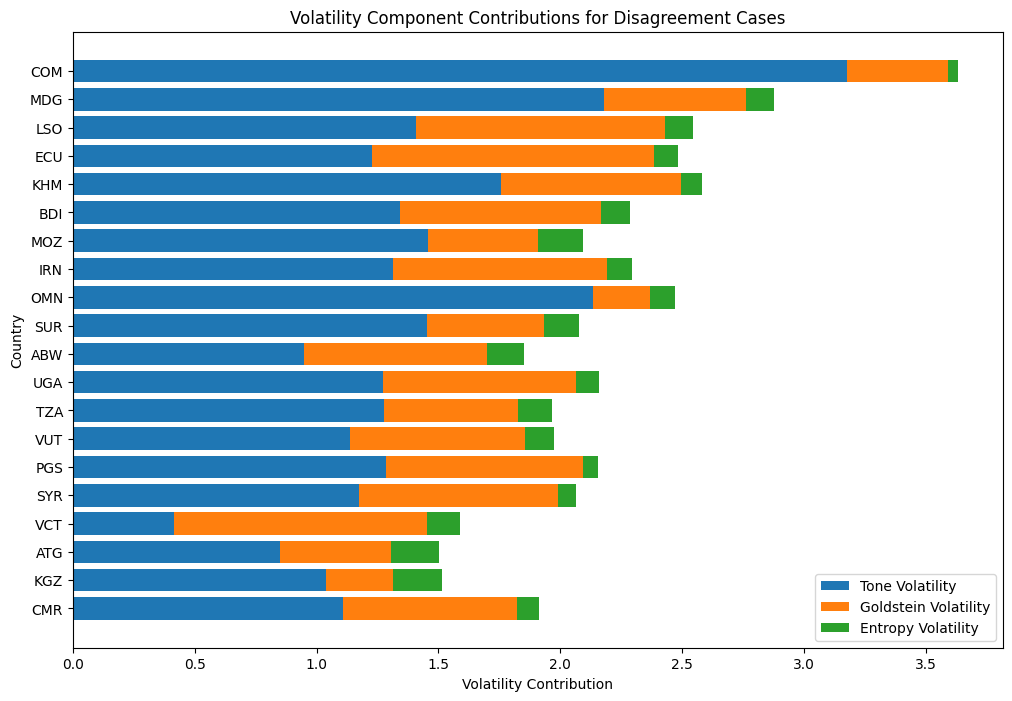

In [66]:
import matplotlib.pyplot as plt

# İlk 20 farklı ülkeyi al
plot_df = diff_df.head(20).copy()

# Ülkeleri NVI'ya göre sırala
plot_df = plot_df.sort_values("NVI", ascending=True)

plt.figure(figsize=(12,8))

plt.barh(plot_df['country'], plot_df['tone_vol'], label='Tone Volatility')
plt.barh(plot_df['country'], plot_df['goldstein_vol'], 
         left=plot_df['tone_vol'], label='Goldstein Volatility')

plt.barh(
    plot_df['country'],
    plot_df['entropy_vol'],
    left=plot_df['tone_vol'] + plot_df['goldstein_vol'],
    label='Entropy Volatility'
)

plt.xlabel("Volatility Contribution")
plt.ylabel("Country")
plt.title("Volatility Component Contributions for Disagreement Cases")
plt.legend()
plt.show()

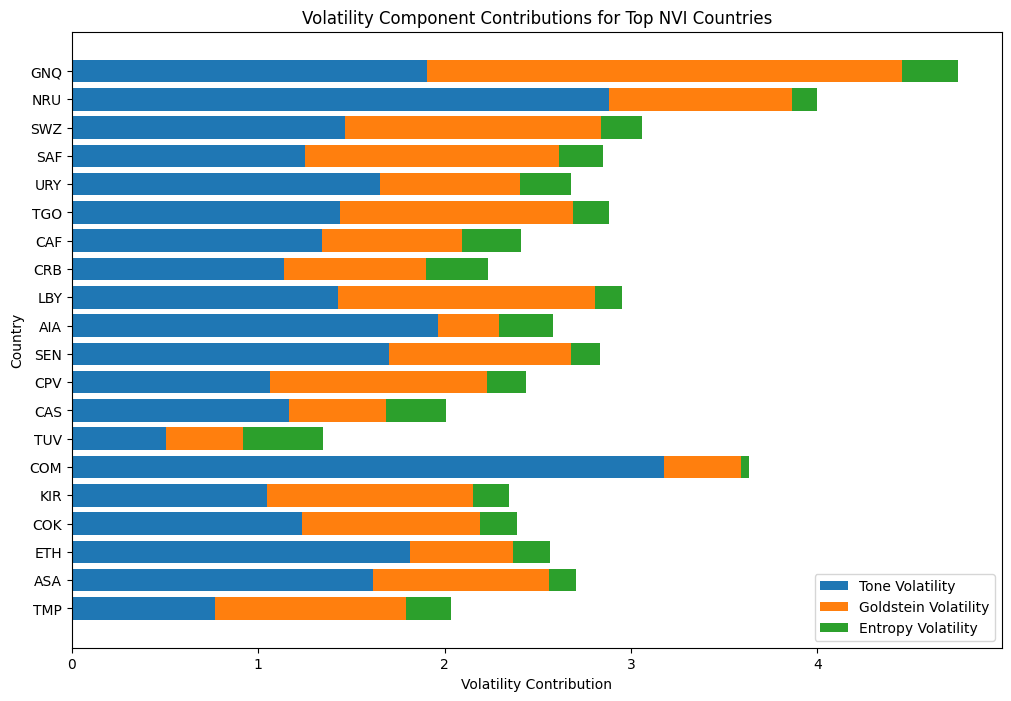

In [67]:
top_nvi_df = df.sort_values("NVI", ascending=False).head(20).copy()

import matplotlib.pyplot as plt

# NVI'ya göre sıralayalım
top_nvi_df = top_nvi_df.sort_values("NVI", ascending=True)

plt.figure(figsize=(12,8))

plt.barh(top_nvi_df['country'], top_nvi_df['tone_vol'], label='Tone Volatility')

plt.barh(
    top_nvi_df['country'],
    top_nvi_df['goldstein_vol'],
    left=top_nvi_df['tone_vol'],
    label='Goldstein Volatility'
)

plt.barh(
    top_nvi_df['country'],
    top_nvi_df['entropy_vol'],
    left=top_nvi_df['tone_vol'] + top_nvi_df['goldstein_vol'],
    label='Entropy Volatility'
)

plt.xlabel("Volatility Contribution")
plt.ylabel("Country")
plt.title("Volatility Component Contributions for Top NVI Countries")
plt.legend()

plt.show()